<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/03_deep_learning/optimization_regularization/experiment_autoencoder_anomaly_detection_mnist_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================
# Autoencoder for Anomaly Detection
# With Proper Evaluation Pipeline
# ============================================

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score

# -------------------------------
# 1. Load Dataset (WITH LABELS)
# -------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# -------------------------------
# 2. Create Binary Labels
# 0 = NORMAL (digit 0)
# 1 = ANOMALY (all other digits)
# -------------------------------
y_test_binary = (y_test != 0).astype(int)

# -------------------------------
# 3. Build Autoencoder
# -------------------------------
input_dim = 784
encoding_dim = 64

input_layer = layers.Input(shape=(input_dim,))

# Encoder
encoded = layers.Dense(128, activation='relu')(input_layer)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = layers.Dense(128, activation='relu')(encoded)
decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)

# Model
autoencoder = models.Model(input_layer, decoded)

# -------------------------------
# 4. Compile
# -------------------------------
autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

# -------------------------------
# 5. Train ONLY on NORMAL DATA
# (IMPORTANT for anomaly detection)
# -------------------------------
x_train_normal = x_train[y_train == 0]

autoencoder.fit(
    x_train_normal, x_train_normal,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

# -------------------------------
# 6. Reconstruction
# -------------------------------
reconstructions = autoencoder.predict(x_test)

# Reconstruction error
mse = np.mean(np.square(x_test - reconstructions), axis=1)

# -------------------------------
# 7. Threshold Selection
# -------------------------------
threshold = np.percentile(mse, 95)

# Predictions
preds = (mse > threshold).astype(int)

# -------------------------------
# 8. Evaluation
# -------------------------------
print("\nClassification Report:\n")
print(classification_report(y_test_binary, preds))

roc_auc = roc_auc_score(y_test_binary, mse)
print(f"ROC-AUC Score: {roc_auc:.4f}")

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.1498 - val_loss: 0.0688
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0633 - val_loss: 0.0548
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0503 - val_loss: 0.0444
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0432 - val_loss: 0.0400
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0392 - val_loss: 0.0364
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0357 - val_loss: 0.0333
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0327 - val_loss: 0.0305
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0300 - val_loss: 0.0279
Epoch 9/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0272 - val_loss: 0.0254
Epoch 10/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0248 - val_loss: 0.0233
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.10     

Average Reconstruction Error: 0.06903798455353204
Threshold: 0.10490087383462482


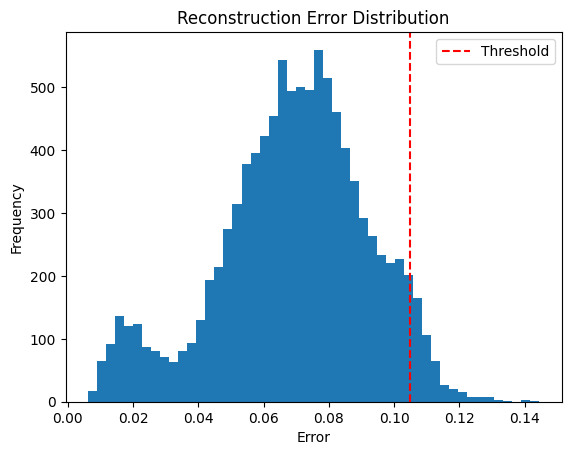


🔍 Classification Report:

              precision    recall  f1-score   support

           0       0.10      1.00      0.19       980
           1       1.00      0.06      0.11      9020

    accuracy                           0.15     10000
   macro avg       0.55      0.53      0.15     10000
weighted avg       0.91      0.15      0.11     10000

Precision: 1.0000
Recall:    0.0554
F1 Score:  0.1050
ROC-AUC:   0.9923


In [5]:
# -------------------------------
# 1. Reconstruction Error (MSE)
# -------------------------------
mse = np.mean(np.square(x_test - reconstructions), axis=1)
print("Average Reconstruction Error:", np.mean(mse))


# -------------------------------
# 2. Threshold Selection
# -------------------------------
threshold = np.percentile(mse, 95)
print("Threshold:", threshold)


# -------------------------------
# 3. Error Distribution (Improved)
# -------------------------------
import matplotlib.pyplot as plt

plt.figure()
plt.hist(mse, bins=50)
plt.axvline(threshold, color='r', linestyle='--', label='Threshold')
plt.title("Reconstruction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.legend()
plt.show()


# -------------------------------
# 4. Create Binary Labels
# 0 = normal (digit 0)
# 1 = anomaly (others)
# -------------------------------
y_test_binary = (y_test != 0).astype(int)


# -------------------------------
# 5. Predictions
# -------------------------------
preds = (mse > threshold).astype(int)


# -------------------------------
# 6. Evaluation Metrics (CORRECT)
# -------------------------------
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score

print("\n🔍 Classification Report:\n")
print(classification_report(y_test_binary, preds))

precision = precision_score(y_test_binary, preds)
recall = recall_score(y_test_binary, preds)
f1 = f1_score(y_test_binary, preds)
roc_auc = roc_auc_score(y_test_binary, mse)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")